In [3]:
from config_schema import HabitatConfig
from utils.habitat_worker import LoggingHabitatWorker
from dataclasses import asdict
from utils import measures

# config = '/Projects/configs/configs/r2r.yaml'
# config = '/Projects/configs/configs/scalevln.yaml'
config = '/Projects/spatial_training/conf/habitat/hm3d_training.yaml'
# config = '/Projects/configs/configs/objectnav_hssd-hab_rgbd.yaml'
cfg = HabitatConfig(
    config_path = config,
    workspace= '/Projects', # folder containing "data",
    split= 'val'
)

worker = LoggingHabitatWorker(**asdict(cfg), logging_output_dir="",
    logger_actor=None)

# from habitat.config.default import get_config
# conf = get_config('/Projects/configs/configs/objectnav_hm3d_rgbd_semantic.yaml')

2026-03-26 21:19:02,783 Initializing dataset ObjectNav-v1


skipping sim initialization since no shards provided, please call assign_shard


In [8]:
worker.full_dataset.get_episode_iterator()

In [29]:
worker.assign_shard()
env = worker.env
hab_env = env.habitat_env
dataset = worker.full_dataset

2026-03-26 21:27:48,191 initializing sim Sim-v0
2026-03-26 21:27:50,991 Initializing task ObjectNav-v1


[Worker] Task Resolved: OBJECTNAV (Goal Key: objectgoal)
using seed: 76143
Actor assigned with shard of 2000 episodes.


In [ ]:
from habitat.core.dataset import EpisodeIterator
env.episode_iterator = EpisodeIterator(dataset.episodes, env._config.DATASET.SHUFFLE, env._config.DATASET.SEED)

In [32]:
env.reset()
print(env.current_episode())
print(dataset.episodes[2])

Renderer: NVIDIA A100-SXM4-80GB/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 550.163.01
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits
BaseEpisode(episode_id='41', scene_id='data/scene_dat

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring


In [53]:
import os
for path in worker.full_dataset.scene_ids:
    try:
        assert(os.path.exists(path))
    except:
        print(f"failed at {path}")

In [35]:
def fix_path(path):
    path_parts = path.split('/')
    fixed_parts = path_parts[:3]+['train']+path_parts[3:]
    return '/'.join(fixed_parts)

fixed_paths = [fix_path(path) for path in worker.full_dataset.scene_ids]
worker.full_dataset.check_config_paths_exist()

# print(fix_path(worker.full_dataset.scene_ids[0]))
# worker.full_dataset.scene_ids[0].split('/')[3:]

TypeError: VLNDatasetV1.check_config_paths_exist() missing 1 required positional argument: 'config'

In [54]:
from habitat.config.default import get_config
conf = get_config('/Projects/configs/configs/objectnav_hm3d_rgbd_semantic.yaml')

#### Assign Shard to Worker
- A "shard" is a list of episode labels of the form f"{scene_id}_{episode_id}"
- Or pass None to imply the shard is the entire underlying dataset
- the worker must be assigned a shard before you can call reset.

In [2]:
worker.assign_shard(None)

2026-01-26 06:01:05,717 initializing sim Sim-v0
2026-01-26 06:01:13,762 Initializing task VLN-v0


in oracle success init: args = (), kwargs = {'sim': HabitatSim(config=Configuration(sim_cfg=<habitat_sim._ext.habitat_sim_bindings.SimulatorConfiguration object at 0x7f76c509f530>, agents=[AgentConfiguration(height=1.5, radius=0.1, sensor_specifications=[<habitat_sim._ext.habitat_sim_bindings.CameraSensorSpec object at 0x7f76c2b5ff10>, <habitat_sim._ext.habitat_sim_bindings.CameraSensorSpec object at 0x7f76c2b5fe20>], action_space={0: ActionSpec(name='stop', actuation=None), 1: ActionSpec(name='move_forward', actuation=ActuationSpec(amount=0.25, constraint=None)), 2: ActionSpec(name='turn_left', actuation=ActuationSpec(amount=30, constraint=None)), 3: ActionSpec(name='turn_right', actuation=ActuationSpec(amount=30, constraint=None))}, body_type='cylinder')], metadata_mediator=None, enable_batch_renderer=False), agents=[Agent(agent_config=AgentConfiguration(height=1.5, radius=0.1, sensor_specifications=[<habitat_sim._ext.habitat_sim_bindings.CameraSensorSpec object at 0x7f76c2b5ff10>, <

In [ ]:
worker.env.habitat_env.episodes

In [8]:
base_env = worker.env.habitat_env
gym_env = worker.env

base_env.task.measurements.measures.items()

odict_items([('distance_to_goal', <habitat.tasks.nav.nav.DistanceToGoal object at 0x7f49041b44c0>), ('success', <habitat.tasks.nav.nav.Success object at 0x7f49041b4640>), ('spl', <habitat.tasks.nav.nav.SPL object at 0x7f49041b4970>), ('oracle_success', <utils.measures.OracleSuccess object at 0x7f49041b4b20>), ('oracle_navigation_error', <utils.measures.OracleNavigationError object at 0x7f4a37675060>), ('oracle_spl', <utils.measures.OracleSPL object at 0x7f4a36deb250>), ('distance_to_goal_reward', <habitat.tasks.nav.nav.DistanceToGoalReward object at 0x7f49041b4d90>), ('top_down_map', <habitat.tasks.nav.nav.TopDownMap object at 0x7f49041b5000>)])

In [ ]:
env

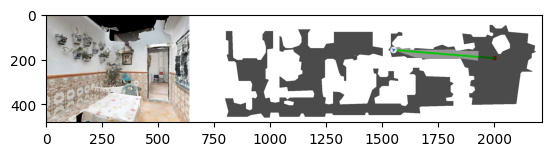

state dict structure: dict_keys(['obs', 'reward', 'done', 'info'])
{'obs': {'compass': array([-1.5543625e-08], dtype=float32), 'depth': array([[[0.17179558],
        [0.17210928],
        [0.1724259 ],
        ...,
        [0.063287  ],
        [0.06321808],
        [0.06314932]],

       [[0.17180613],
        [0.17212164],
        [0.17243654],
        ...,
        [0.06328366],
        [0.06321475],
        [0.06314599]],

       [[0.1721923 ],
        [0.17219584],
        [0.17244717],
        ...,
        [0.06328056],
        [0.06321165],
        [0.0631467 ]],

       ...,

       [[0.19988783],
        [0.20024331],
        [0.20060244],
        ...,
        [0.06805854],
        [0.06803757],
        [0.0680166 ]],

       [[0.19987354],
        [0.20023134],
        [0.20058803],
        ...,
        [0.06792684],
        [0.06790594],
        [0.06788506]],

       [[0.19985925],
        [0.20021701],
        [0.20057607],
        ...,
        [0.06779563],
        [0.0677

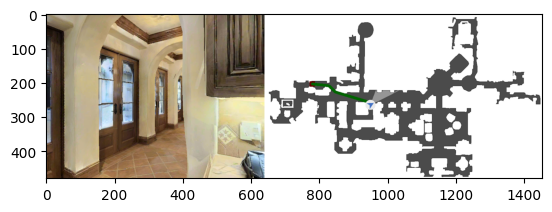

In [3]:
import matplotlib.pyplot as plt
worker.output_schema = worker._generate_auto_schema(True) # force no filtering
state_dict = worker.reset()
print(f"state dict structure: {state_dict.keys()}")
print(state_dict)
import matplotlib.pyplot as plt
from habitat.utils.visualizations import utils as vut
plt.imshow(vut.observations_to_image(worker._apply_schema(state_dict['obs'],{"rgb":True}),state_dict['info']))


In [23]:
state_dict['info']
class ObjectNavOracle:
    def __init__(self, env, success_distance,goal_radius=0.2,goal_measure="distance_to_goal"):
        from habitat.tasks.nav.shortest_path_follower import ShortestPathFollower
        """
        High-performance Oracle using MultiGoalShortestPath and episode caching.
        
        :param env: Habitat Environment. MUST NOT be RL wrapped.
        :param success_distance: Distance threshold to consider goal reached
        :param goal_radius: Radius for the low-level ShortestPathFollower
        """
        self.sim = env.sim
        self.env = env
        self.success_distance = success_distance
        self.goal_measure = goal_measure

        # We assume goal_radius for the low-level follower is similar to success_dist
        # You can tune this if the agent stops too early/late.
        self.follower = ShortestPathFollower(
            self.sim, 
            goal_radius=goal_radius, 
            return_one_hot=False
        )
        
        # Caching mechanisms
        self._cached_episode_id = None
        self._cached_candidates = None # List of Vector3 targets

    def _refresh_candidates(self, episode):
        import numpy as np
        """
        Parses episode goals once and stores all valid navigable target points.
        """
        candidates = []
        for goal in episode.goals:
            # 1. Prefer explicit ViewPoints (guaranteed navigable locations)
            if hasattr(goal, 'view_points') and goal.view_points:
                candidates.extend([self.sim.pathfinder.snap_point(vp.agent_state.position) for vp in goal.view_points])
            else:
                # 2. Fallback: Snap object position to NavMesh
                snapped_pos = self.sim.pathfinder.snap_point(goal.position)
                # Check if snap was successful (isnan check is robust for Vector3)
                if not np.isnan(snapped_pos[0]):
                    candidates.append(snapped_pos)
        
        # Fallback if metadata is totally broken (prevents crash)
        if not candidates:
            candidates = [g.position for g in episode.goals]
            
        self._cached_candidates = candidates
        self._cached_episode_id = episode.episode_id

    def get_best_action(self):
        import habitat_sim
        """
        Returns the optimal action index (int).
        Runtime: < 2ms (vs ~300ms unoptimized).
        """
        episode = self.env.current_episode
        agent_state = self.sim.get_agent_state()
        # 1. Cache Check
        if self._cached_episode_id != episode.episode_id:
            self._refresh_candidates(episode)
            
        # If no candidates exist (broken episode), Stop.
        if not self._cached_candidates:
            return 0 

        agent_pos = self.sim.pathfinder.snap_point(agent_state.position)
        
        # 2. MultiGoal Shortest Path (C++ backend)
        # Finds the closest point among all candidates in one pass.
        path = habitat_sim.MultiGoalShortestPath()
        path.requested_start = agent_pos
        path.requested_ends = self._cached_candidates
        
        found = self.sim.pathfinder.find_path(path)

        # 3. Decision Logic
        if not found:
            print("not found")
            # Agent is on an island or navmesh is broken. Return STOP (0) or Forward(1)
            return 0 
        distance_to_goal = self.env.task.measurements.measures[self.goal_measure].get_metric()
        if distance_to_goal is not None and distance_to_goal < self.success_distance:
            print("stopping")
            return 0  # STOP
        best_target = path.points[-1]
        print(best_target)
        print(agent_pos)
        return self.follower.get_next_action(best_target)

In [24]:

worker.nav_oracle = ObjectNavOracle(worker.env.habitat_env,1.0)
worker.nav_oracle.get_best_action()

Vector(0.685071, 0.00332105, -13.7198)
Vector(9.38184, 0.203321, -13.7165)


3

In [22]:
worker.nav_oracle._cached_candidates

[Vector(0.685071, 0.00332105, -13.7198)]

#### Interactive Play.
- type integers for discrete action
- type 7 to exit

/tmp/ipykernel_2921074/2136096396.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


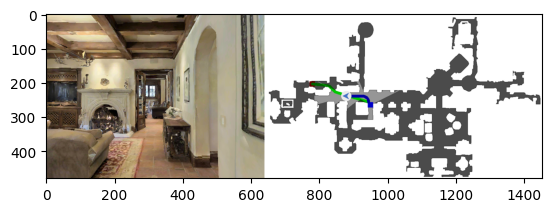

KeyboardInterrupt: Interrupted by user

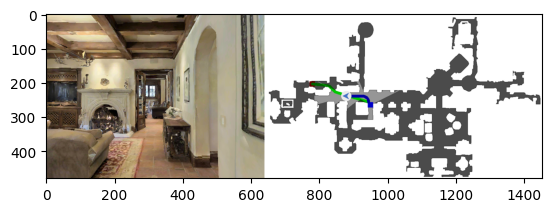

: 

In [ ]:
action = 1
from IPython.display import display, clear_output
fig, ax = plt.subplots()
while action!=0 and action!=7:
    
    # ax.imshow(state_dict['obs']['rgb'])

    ax.imshow(vut.observations_to_image(worker._apply_schema(state_dict['obs'],{"rgb":True}),state_dict['info']))
    fig.show()
    display(fig)
    action = input(f"instruction:\n {state_dict['obs']['instruction']}\n \nnext move?")
    action = int(action)
    if action == 7:
        break
    clear_output()
    print(f"reward: {state_dict['reward']}")
    try:
        print(f"exploration: {state_dict['exploration_delta']}")
    except:
        pass
    state_dict = worker.step(action)
    

In [35]:
state_dict

{'obs': {'compass': array([-1.0471977], dtype=float32),
  'depth': array([[[0.12469812],
          [0.12482151],
          [0.12494515],
          ...,
          [0.20028631],
          [0.20028873],
          [0.20029111]],
  
         [[0.12470184],
          [0.12482522],
          [0.1249498 ],
          ...,
          [0.20113632],
          [0.20113873],
          [0.20114115]],
  
         [[0.12470647],
          [0.12482987],
          [0.12495352],
          ...,
          [0.20199116],
          [0.20199358],
          [0.201996  ]],
  
         ...,
  
         [[0.12627676],
          [0.12640235],
          [0.12652819],
          ...,
          [0.21712676],
          [0.21712394],
          [0.21712115]],
  
         [[0.12628058],
          [0.12640712],
          [0.12653296],
          ...,
          [0.2162257 ],
          [0.21622011],
          [0.21621732]],
  
         [[0.12628533],
          [0.12641093],
          [0.12653677],
          ...,
          [0.215

In [23]:
state_tuple = worker.env.step(0)

3.0

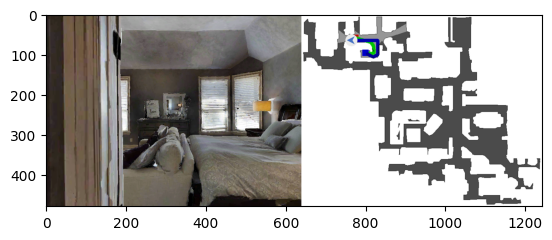

In [66]:
from habitat.utils.visualizations import utils as vut
plt.imshow(vut.observations_to_image(worker._apply_schema(state_dict['obs'],{"rgb":True}),state_dict['info']))


In [21]:
state_dict

{'obs': {'compass': array([-3.091077e-08], dtype=float32),
  'depth': array([[[0.03209643],
          [0.03226613],
          [0.03243762],
          ...,
          [0.21747856],
          [0.2174983 ],
          [0.21751805]],
  
         [[0.0320968 ],
          [0.03226649],
          [0.03243799],
          ...,
          [0.2183816 ],
          [0.21840148],
          [0.21842138]],
  
         [[0.03209717],
          [0.03226687],
          [0.03243837],
          ...,
          [0.21929213],
          [0.21931222],
          [0.2193323 ]],
  
         ...,
  
         [[0.0321292 ],
          [0.032323  ],
          [0.03251954],
          ...,
          [0.22413178],
          [0.2241288 ],
          [0.2241228 ]],
  
         [[0.03212864],
          [0.03232244],
          [0.0325186 ],
          ...,
          [0.22320445],
          [0.22320445],
          [0.22320147]],
  
         [[0.03212809],
          [0.03232189],
          [0.03251803],
          ...,
          [0.

In [47]:
state_dict['obs']

{'compass': array([-1.5543625e-08], dtype=float32),
 'depth': array([[[0.24265817],
         [0.2430413 ],
         [0.24342568],
         ...,
         [0.2582606 ],
         [0.25827652],
         [0.2582964 ]],
 
        [[0.24279158],
         [0.2431787 ],
         [0.24356349],
         ...,
         [0.2593866 ],
         [0.25940666],
         [0.2594267 ]],
 
        [[0.2429287 ],
         [0.24331269],
         [0.24370149],
         ...,
         [0.26052648],
         [0.2605467 ],
         [0.26056293]],
 
        ...,
 
        [[0.22499745],
         [0.22502461],
         [0.22505479],
         ...,
         [0.08455363],
         [0.08446424],
         [0.08437546]],
 
        [[0.22411084],
         [0.22414076],
         [0.2241677 ],
         ...,
         [0.08459712],
         [0.08450763],
         [0.08441833]],
 
        [[0.22323115],
         [0.22325492],
         [0.22326085],
         ...,
         [0.08464022],
         [0.08455107],
         [0.08446168

In [ ]:
state_dict 

In [12]:
worker.output_schema

{'obs': {'rgb': True, 'goal_name': True, 'patch_coords': False},
 'info': {'episode_label': True,
  'spl': True,
  'soft_spl': True,
  'success': True,
  'distance_to_goal': True},
 'done': True,
 'reward': True,
 'stuck': True,
 'fp_stop': True}